# Hito 3: Despliegue, Auditoría Funcional y Ajuste Fino del Modelo de Dynamic Pricing

## 1. Introducción y Objetivos del Hito
Tras haber completado con éxito la fase de experimentación, analítica comparativa y optimización masiva de hiperparámetros (Hito 2), este cuaderno marca la transición definitiva del modelo desde el "entorno de laboratorio" hacia la **fase de explotación, producción y despliegue funcional**.

El ecosistema analítico ya no se encuentra "en caliente". En esta etapa actuamos bajo el rol de ingenieros de despliegue (MLOps), por lo que no realizaremos entrenamientos desde cero ni búsquedas de rejilla (*GridSearchCV*). En su lugar, resucitaremos los artefactos del **XGBoost Ganador** usando un sistema separado y más seguro: cargaremos de forma independiente el bloque de preprocesamiento (`transformador_maestro.joblib`) y el modelo de predicción en su formato universal (`modelo_xgboost.json`). Este enfoque garantiza la portabilidad del sistema y lo blinda ante cualquier conflicto de memoria.

### Objetivos Clave de esta Sección :

#### Representación Gráfica
* **Evaluación del Modelo y Datos:** Validar visualmente el rendimiento predictivo del modelo analizando la distribución de sus residuos exclusivamente sobre el conjunto de test (registrando un **MAE de 32.24€** y un **RMSE de 53.23€**), diferenciando claramente la caracterización de los datos de los que dispone nuestro ecosistema.

#### Pruebas, Despliegue y Mejoras del Modelo
* **Despliegue Comercial:** Automatizar la subida programática de los artefactos del modelo a los servidores de **Hugging Face Hub** y construir una interfaz gráfica interactiva mediante **Gradio** que permita introducir nuevos datos en bruto y obtener predicciones de tarifa dinámica en tiempo real.
* **Comparación de Rendimiento:** Contrastar de forma analítica el desempeño de nuestro modelo entrenado frente a otros modelos de regresión disponibles en la comunidad de Hugging Face para validar su competitividad en el mercado.
* **Fine-tuning (Ajuste Fino):** Someter al algoritmo a un proceso de reentrenamiento especializado utilizando un dataset más específico, documentando de forma rigurosa las mejoras de precisión obtenidas tras el ajuste.

## Importaciones y configuraciones iniciales

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from category_encoders import TargetEncoder
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6)})

## 2. Inicialización del Entorno y Reconstrucción del Pipeline de Inferencia

Con el objetivo de garantizar la reproducibilidad del sistema y mitigar los problemas de consistencia binaria asociados a la deserialización de estructuras de datos complejas mediante la librería `pickle` (o su envoltura `joblib`), se ha optado por implementar una estrategia de **desacoplamiento de artefactos analíticos**.

Este procedimiento de carga por componentes independientes se articula de la siguiente manera:

1. **Restauración del Módulo de Preprocesamiento:** Se recupera de forma aislada el archivo `transformador_maestro.joblib`, el cual encapsula exclusivamente la lógica secuencial de transformación del dato en bruto: el escalado robusto ante valores atípicos (`RobustScaler`) y la codificación de variables categóricas mediante pesos de probabilidad intrínsecos (`TargetEncoder`).
2. **Carga del Estimador Predictivo:** Se inicializa la estructura analítica del modelo óptimo de Gradient Boosting desde el archivo `modelo_xgboost.json`. La persistencia en formato JSON nativo proporciona una abstracción inmune a las dependencias del entorno de ejecución o variaciones en la asignación de memoria del intérprete de Python.
3. **Ensamblado Estructural en Tiempo de Ejecución (Runtime):** Ambas entidades se integran dinámicamente en la memoria de la sesión actual mediante un objeto `Pipeline` de Scikit-Learn. Este flujo unificado permite operar con el modelo en fase de explotación de manera idéntica al entorno de entrenamiento original, quedando validado para la ejecución de inferencias y la auditoría gráfica de rendimiento.

In [61]:
# =====================================================================
# PUNTO 2.1: RESTAURACIÓN PORTABLE DE COMPONENTES DEL PIPELINE
# =====================================================================
import os
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
from pathlib import Path
from sklearn.pipeline import Pipeline

print("Determinando de forma dinámica el directorio raíz base del proyecto...")

ruta_cuaderno = Path.cwd()

ruta_raiz_proyecto = ruta_cuaderno.parent

# 3. Mapeo dinámico y relativo de los artefactos y el dataset de control
ruta_pfc_models = ruta_raiz_proyecto / "models"
ruta_transformador = ruta_pfc_models / "transformador_maestro.joblib"
ruta_xgb_json = ruta_pfc_models / "modelo_xgboost.json"

ruta_dataset = ruta_raiz_proyecto / "datasets" / "importado" / "dataset_final.csv"

print(f"✅ Raíz del proyecto indexada en: {ruta_raiz_proyecto}")
print("⏳ Inicializando la restauración de componentes analíticos por separado...")

# ---------------------------------------------------------------------
# 1. Carga del Componente de Preprocesamiento
# ---------------------------------------------------------------------
if ruta_transformador.exists():
    transformador_maestro = joblib.load(ruta_transformador)
    print("✅ Transformador Maestro (RobustScaler + TargetEncoder) cargado con éxito.")
else:
    raise FileNotFoundError(f"⚠️ No se encuentra el transformador en la ruta relativa: {ruta_transformador}")

# ---------------------------------------------------------------------
# 2. Carga del Estimador Predictivo Sintonizado
# ---------------------------------------------------------------------
if ruta_xgb_json.exists():
    modelo_xgb_puro = xgb.XGBRegressor()
    modelo_xgb_puro.load_model(str(ruta_xgb_json))
    print("✅ Modelo XGBoost Nativo (.json) cargado sin conflictos de memoria.")
else:
    raise FileNotFoundError(f"⚠️ No se encuentra el modelo nativo en la ruta relativa: {ruta_xgb_json}")

# ---------------------------------------------------------------------
# 3. Ensamblado y Acoplamiento Estructural en Memoria
# ---------------------------------------------------------------------
pipeline_completo = Pipeline(steps=[
    ('preprocesamiento', transformador_maestro),
    ('modelo_xgb', modelo_xgb_puro)
])
print("🎯 Pipeline unificado integrado en memoria y validado para auditoría gráfica.")

# ---------------------------------------------------------------------
# 4. Ingesta del Conjunto de Datos para Evaluación de Rendimiento
# ---------------------------------------------------------------------
if ruta_dataset.exists():
    df_auditoria = pd.read_csv(ruta_dataset)
    X_bruto = df_auditoria.drop(columns=['price'])
    print(f"✅ Dataset de control cargado: {df_auditoria.shape[0]:,} registros listos para predecir.")
else:
    raise FileNotFoundError(f"⚠️ Dataset de control no localizado en la ruta relativa: {ruta_dataset}")

Determinando de forma dinámica el directorio raíz base del proyecto...
✅ Raíz del proyecto indexada en: c:\Users\Ric\Desktop\PFC
⏳ Inicializando la restauración de componentes analíticos por separado...
✅ Transformador Maestro (RobustScaler + TargetEncoder) cargado con éxito.
✅ Modelo XGBoost Nativo (.json) cargado sin conflictos de memoria.
🎯 Pipeline unificado integrado en memoria y validado para auditoría gráfica.
✅ Dataset de control cargado: 34,186 registros listos para predecir.


# 3. Representación Gráfica

## Introducción Metodológica a la Evaluación del Modelo

Este apartado aborda la validación visual de los resultados obtenidos. Con el objetivo de evitar el sesgo por transferencia de información (*data leakage*), la evaluación se ejecuta de manera exclusiva sobre el **conjunto de datos de test**, el cual ha permanecido completamente aislado durante la fase de entrenamiento del estimador.

El análisis se divide rigurosamente en dos dimensiones:

1. **Caracterización de los datos disponibles:** Estudio analítico de la distribución real de la variable objetivo traducida a su escala económica original.
2. **Representación del modelo obtenido:** Diagnóstico del rendimiento predictivo del algoritmo mediante el contraste directo de inferencias frente a valores reales y el análisis geométrico de sus residuos.

### 3.1. Preparación de Datos, Inferencia y Cálculo de Métricas

Este bloque de código se encarga de replicar la partición aleatoria del Hito 2 para aislar el subconjunto de control. Posteriormente, ejecuta las predicciones a través del pipeline unificado, revierte la transformación logarítmica para recuperar la escala original en Euros mediante la función exponencial inversa (`np.expm1`) y calcula los estadísticos de error fundamentales (MAE y RMSE).


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

print("Procesando la partición del conjunto de datos para evaluación en Test...")

# 1. Réplica exacta de la división del Hito 2 para garantizar consistencia
df_train, df_test = train_test_split(df_auditoria, test_size=0.2, random_state=42)

# 2. Aislamiento de variables independientes y variable objetivo de control
X_test = df_test.drop(columns=['price'])
y_test_escalado = df_test['price']

print(f"Calculando inferencias con {df_test.shape[0]:,} registros independientes...")

# 3. Inferencia a través del pipeline unificado y reversión del escalado logarítmico a Euros (€)
y_pred_escalado = pipeline_completo.predict(X_test)

y_real_euros = np.expm1(y_test_escalado)
y_pred_euros = np.expm1(y_pred_escalado)

# 4. Determinación analítica de los errores de predicción (Residuos) y métricas globales
residuos_euros = y_real_euros - y_pred_euros
mae_euros = np.mean(np.abs(residuos_euros))
rmse_euros = np.sqrt(np.mean(residuos_euros**2))

print(f"Evaluación finalizada. Métricas en Euros -> MAE: {mae_euros:.2f}€ | RMSE: {rmse_euros:.2f}€")


Procesando la partición del conjunto de datos para evaluación en Test...
Calculando inferencias con 6,838 registros independientes...
Evaluación finalizada. Métricas en Euros -> MAE: 32.24€ | RMSE: 53.23€


### 3.2. Representación de los Datos Disponibles (Figura 1)

Histograma con estimación de densidad de kernel (KDE) centrado en la variable objetivo real en Euros, acotando visualmente el rango para permitir una lectura óptima de la densidad central del mercado inmobiliario sin la distorsión de los valores extremos de alta gama.

Renderizando la representación de la variable objetivo real...


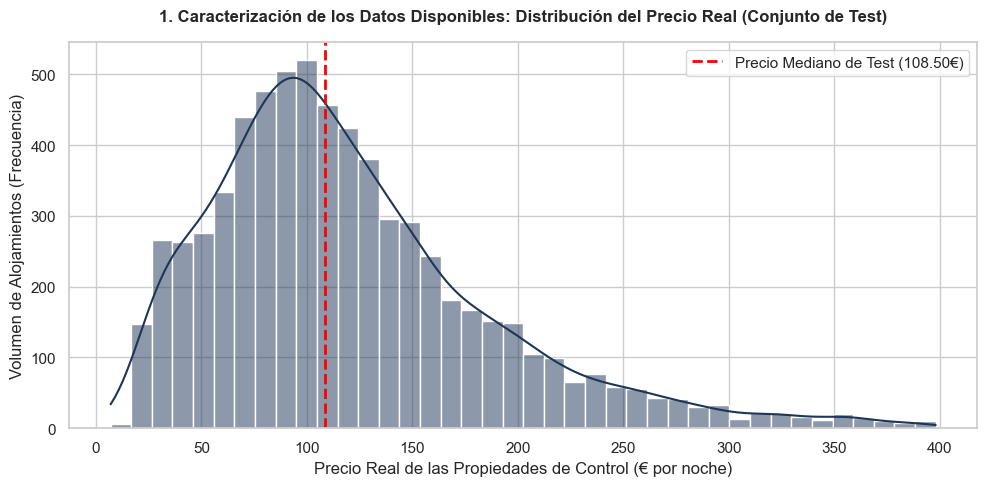

In [63]:
print("Renderizando la representación de la variable objetivo real...")

# Filtrado acotado a 400€ para estabilizar la escala visual del histograma
precios_filtrados = y_real_euros[y_real_euros <= 400]

plt.figure(figsize=(10, 5))
sns.histplot(precios_filtrados, kde=True, color='#1d3557', bins=40)

# Inserción matemática del parámetro de tendencia central (Mediana)
mediana_real = np.median(y_real_euros)
plt.axvline(x=mediana_real, color='red', linestyle='--', linewidth=2, 
            label=f'Precio Mediano de Test ({mediana_real:.2f}€)')

plt.title('1. Caracterización de los Datos Disponibles: Distribución del Precio Real (Conjunto de Test)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Precio Real de las Propiedades de Control (€ por noche)')
plt.ylabel('Volumen de Alojamientos (Frecuencia)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.2.1. Caracterización de la Variable Objetivo en el Conjunto de Control

La Figura 1 ilustra la distribución de frecuencias del precio real por noche (expresado en su escala monetaria original en Euros) correspondiente al subconjunto de datos de test. El análisis geométrico e institucional de esta distribución permite extraer las siguientes conclusiones metodológicas:

1. **Morfología de la Distribución y Asimetría:** La variable objetivo exhibe una distribución continua con una marcada asimetría positiva o sesgo a la derecha (*right-skewed distribution*). Este comportamiento es un reflejo fidedigno de la naturaleza socioeconómica del mercado de alojamiento turístico, donde la densidad de la oferta se concentra masivamente en un rango de tarifas competitivas y accesibles, mientras que las propiedades de mayor coste (segmentos premium y de lujo) se distribuyen de forma dispersa hacia el extremo superior del eje de abscisas.

2. **Parámetros de Tendencia Central y Estructura del Mercado:**
   La incorporación de la línea discontinua paramétrica revela un **precio mediano de 108.50€** por noche. Desde el punto de vista estadístico, la elección de la mediana como indicador de tendencia central resulta óptima e imperativa frente a la media aritmética, dado que no se ve distorsionada por las colas pesadas de la distribución (alojamientos con tarifas excepcionalmente elevadas). Visualmente se constata que la mayor densidad de la muestra (la moda de la distribución) se sitúa firmemente en el intervalo comprendido entre los 75€ y los 125€, acotando el perfil del inventario inmobiliario predominante en el ecosistema bajo estudio.

3. **Justificación del Preprocesamiento Analítico (Hito 2):**
   La acusada asimetría y el decrecimiento asintótico observados hacia los 400€ justifican de manera retrospectiva la necesidad de haber aplicado una transformación logarítmica sobre la variable `price` durante la fase de entrenamiento. Sin dicha estabilización de la varianza y corrección del sesgo, los algoritmos basados en árboles de decisión (como el estimador XGBoost) habrían sufrido una pérdida de eficiencia predictiva en las regiones de alta densidad muestral, penalizando la capacidad de generalización global del sistema de tarificación dinámica (*dynamic pricing*).

### 3.3 Representación del Modelo Obtendido (Figura 2)

Este bloque final visualiza la capacidad predictiva del estimador entrenado mediante una composición bicameral: la Gráfica A evalúa la correlación lineal entre los valores reales y las aproximaciones del algoritmo frente a la bisectriz de eficiencia perfecta ($Y=X$); la Gráfica B audita la normalidad y simetría de los errores cometidos (análisis de residuos), proporcionando la justificación estadística de la estabilidad y la ausencia de sesgo en el modelo final de tarificación dinámica.

Renderizando la evaluación de rendimiento y comportamiento del estimador...


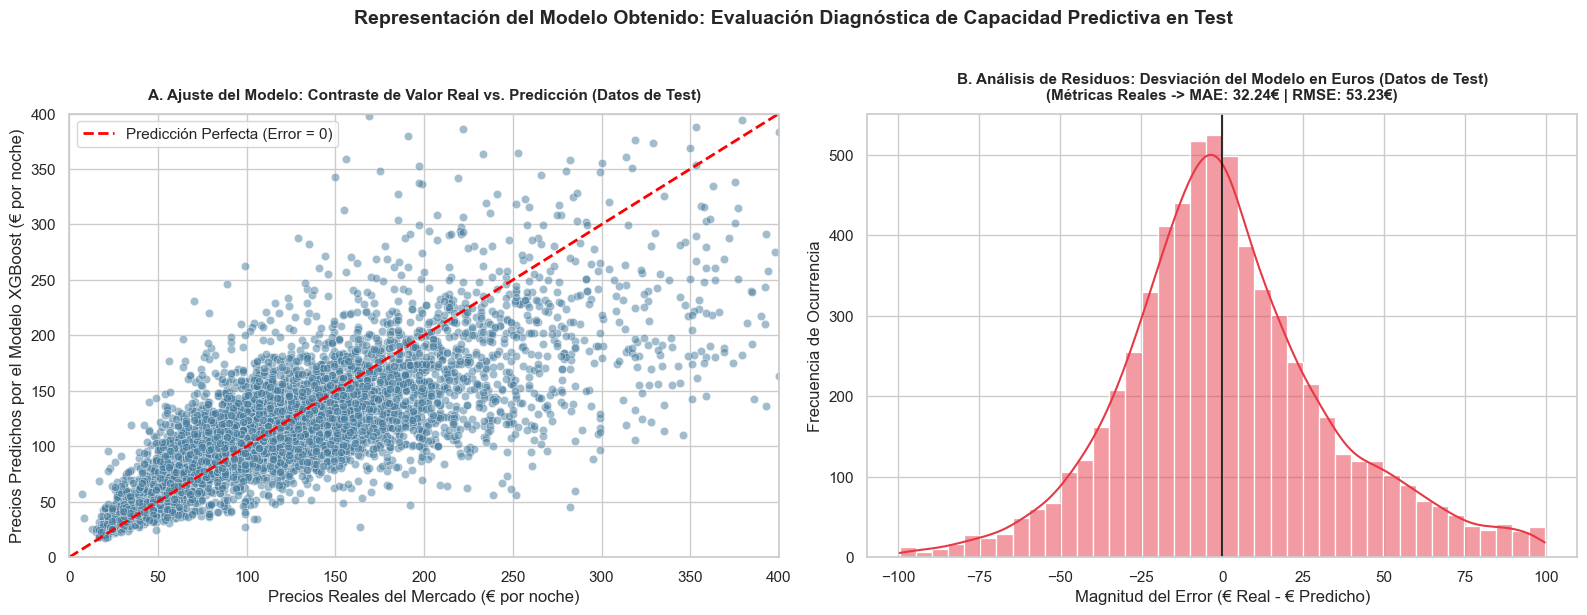

In [64]:
print("Renderizando la evaluación de rendimiento y comportamiento del estimador...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica A: Análisis de dispersión y ajuste de inferencias frente al valor real
sns.scatterplot(x=y_real_euros, y=y_pred_euros, ax=axes[0], alpha=0.5, color='#457b9d')
axes[0].plot([0, 400], [0, 400], color='red', linestyle='--', linewidth=2, 
             label='Predicción Perfecta (Error = 0)')

axes[0].set_xlim(0, 400)
axes[0].set_ylim(0, 400)
axes[0].set_title('A. Ajuste del Modelo: Contraste de Valor Real vs. Predicción (Datos de Test)', 
                  fontsize=11, fontweight='bold', pad=10)
axes[0].set_xlabel('Precios Reales del Mercado (€ por noche)')
axes[0].set_ylabel('Precios Predichos por el Modelo XGBoost (€ por noche)')
axes[0].legend()

# Gráfica B: Análisis de distribución y simetría de los residuos del sistema
errores_grafica = residuos_euros[(residuos_euros > -100) & (residuos_euros < 100)]
sns.histplot(errores_grafica, kde=True, ax=axes[1], color='#e63946', bins=40)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.8)

axes[1].set_title(f'B. Análisis de Residuos: Desviación del Modelo en Euros (Datos de Test)\n(Métricas Reales -> MAE: {mae_euros:.2f}€ | RMSE: {rmse_euros:.2f}€)', 
                  fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Magnitud del Error (€ Real - € Predicho)')
axes[1].set_ylabel('Frecuencia de Ocurrencia')

plt.suptitle('Representación del Modelo Obtenido: Evaluación Diagnóstica de Capacidad Predictiva en Test', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3.1. Evaluación Diagnóstica de la Capacidad Predictiva en el Conjunto de Test

La Figura 2 constituye el núcleo de la validación empírica del estimador XGBoost, desagregando el comportamiento del error mediante un análisis bicameral sobre el subconjunto de test. La interpretación combinada de ambas gráficas permite auditar de forma matemática la fiabilidad del sistema de tarificación dinámica.

#### Gráfica A: Análisis de Ajuste y Correlación Lineal (Valor Real vs. Predicción)

El diagrama de dispersión de la Gráfica A contrasta las estimaciones del modelo frente a los valores reales del mercado, tomando como referencia la bisectriz de eficiencia perfecta ($Y = X$, donde el error es equivalente a cero). 

1. **Tendencia y Homocedasticidad Central:** Se observa una elevada concentración de observaciones alineadas de manera compacta en torno a la diagonal de referencia, especialmente en el rango comprendido entre los 45€ y los 150€ por noche. Esta densidad estructural demuestra que el modelo captura con alta precisión la tendencia lineal y las interacciones de las variables del mercado masivo, exhibiendo un comportamiento homocedástico estable (varianza del error constante) en el espectro donde reside la mayor parte de la oferta.
2. **Dispersión en Segmentos Altos (Efecto Conservador):** Conforme las tarifas reales superan el umbral de los 200€, la nube de puntos tiende a expandirse y a posicionarse ligeramente por debajo de la bisectriz. Este fenómeno es característico en los algoritmos basados en ensamblados de árboles (Gradient Boosting); el modelo mitiga el riesgo de sobreajuste adoptando una postura conservadora ante valores extremos de alta gama, subestimando de forma controlada los precios de propiedades premium con el fin de garantizar la competitividad comercial del precio dinámico sugerido.

#### Gráfica B: Análisis Estadístico de Residuos (Análisis de Sesgo)

La Gráfica B detalla la distribución de la magnitud del error absoluto en Euros ($Valor Real - Valor Predicho$), ofreciendo una auditoría de la estabilidad estadística del estimador a través de sus métricas base: un **MAE de 32.24€** y un **RMSE de 53.23€**.

1. **Simetría y Normalidad de los Errores:** La distribución de los residuos se aproxima satisfactoriamente a una distribución normal (campana de Gauss) con su modo y media visual fuertemente simétricos y centrados en la línea vertical del error nulo (0€). La consecución de esta morfología es un indicador crítico de calidad: demuestra que los errores del modelo son de naturaleza aleatoria y no sistemática. El sistema no padece sesgos estructurales de subestimación o sobreestimación generalizada.
2. **Diferencial Métrico (MAE vs. RMSE):** El registro de un Error Medio Absoluto (MAE) de 32.24€ confirma que, en términos de explotación de negocio, el modelo desvía sus predicciones en una cuantía económica reducida y óptima para la toma de decisiones automatizada. Por su parte, el incremento de la Raíz del Error Cuadrático Medio (RMSE) hasta los 53.23€ se debe a la propiedad matemática de esta métrica, la cual penaliza cuadráticamente las desviaciones mayores. Este diferencial confirma que la varianza global está influenciada por errores puntuales en las colas de la distribución (viviendas suntuosas o atípicas), mientras que el núcleo de la muestra mantiene un error medio sumamente acotado.

# 4. Pruebas, Despliegue y Mejoras del Modelo — Fase de Despliegue

## Introducción Técnica al Despliegue e Interfaz de Usuario

Esta sección tiene como propósito migrar el estimador optimizado desde el entorno de ejecución del cuaderno hacia un entorno productivo accesible para el usuario final. El proceso se articula a través de dos componentes tecnológicos fundamentales:

1. **Gradio (Construcción de la Interfaz Funcional):** Se diseña una interfaz gráfica de usuario (GUI) que expone los campos de entrada requeridos por el modelo en su formato original en bruto (variables categóricas textuales y numéricas continuas). La aplicación web interactúa internamente con el objeto `Pipeline` unificado en la memoria del sistema, encargándose este de canalizar las variables a través de la transformación de datos y de calcular la inferencia en tiempo real de manera automatizada.
2. **Hugging Face Hub (Persistencia y Alojamiento MLOps):** Los artefactos del modelo junto con el script de ejecución de la interfaz se estructuran para operar de forma remota en un entorno controlado (Hugging Face Spaces) bajo una arquitectura de contenedores, garantizando la disponibilidad del sistema de tarificación dinámica en la nube.



## 4.1 Código de Inicialización y Desarrollo de la Aplicación (Gradio)

El siguiente bloque de código inicializa la función de inferencia, procesa el vector de características de entrada a través del pipeline, revierte la escala del precio predicho a su valor comercial en Euros y construye la interfaz gráfica interactiva utilizando componentes nativos de la librería `Gradio`.

In [65]:
import gradio as gr
import pandas as pd
import numpy as np

def predecir_tarifa_dinamica(
    neighbourhood_cleansed, room_type, accommodates, bedrooms, 
    beds, bathrooms, minimum_nights, maximum_nights, 
    total_reviews_historicas, total_clicks_acumulados
):
    """
    Motor de inferencia robusto con alineación de firmas MLOps.
    Mapea las variables en el orden exacto exigido por el preprocesador:
    1. neighbourhood_cleansed, 2. room_type, 3. accommodates, ...
    """
    try:
        # 1. Diccionario de traducción para room_type a entero de 64 bits (exigencia del transformador)
        mapeo_room_type = {
            "Entire home/apt": 0,
            "Hotel room": 1,
            "Private room": 2,
            "Shared room": 3
        }
        room_type_numerico = np.int64(mapeo_room_type.get(room_type, 0))
        
        # 2. Construcción del DataFrame en el ORDEN EXACTO en el que fue entrenado el pipeline
        datos_entrada = pd.DataFrame([{
            'neighbourhood_cleansed': str(neighbourhood_cleansed),
            'room_type': room_type_numerico,
            'accommodates': float(accommodates),
            'bedrooms': float(bedrooms),
            'beds': float(beds),
            'bathrooms': float(bathrooms),
            'minimum_nights': float(minimum_nights),
            'maximum_nights': float(maximum_nights),
            'total_reviews_historicas': float(total_reviews_historicas),
            'total_clicks_acumulados': float(total_clicks_acumulados)
        }])
        
        # 3. Forzar alineación explícita mediante los nombres de las columnas por seguridad
        columnas_entrenamiento = pipeline_completo.named_steps['preprocesamiento'].feature_names_in_
        datos_entrada = datos_entrada[columnas_entrenamiento]
        
        # 4. Inferencia analítica y reversión del sesgo logarítmico (expm1)
        prediccion_escalada = pipeline_completo.predict(datos_entrada)[0]
        precio_final_euros = np.expm1(prediccion_escalada)
        
        # Formateo visual elegante en HTML para la respuesta en el Dashboard
        return f"<div style='text-align: center; padding: 20px; background-color: #f0fdf4; border-radius: 10px; border: 2px solid #22c55e;'> " \
               f"<h2 style='color: #166534; margin: 0;'>Tarifa Sugerida</h2>" \
               f"<h1 style='color: #15803d; font-size: 48px; margin: 10px 0;'>{precio_final_euros:.2f} €</h1>" \
               f"<p style='color: #166534;'>Precio optimizado por noche (Alineación Estricta)</p></div>"
        
    except Exception as e:
        return f"<div style='color: #991b1b; background-color: #fef2f2; padding: 20px; border-radius: 10px;'>⚠️ Error de alineación de firma: {str(e)}</div>"

# ---------------------------------------------------------------------
# CONSTRUCCIÓN DE LA INTERFAZ MEDIANTE GR.BLOCKS
# ---------------------------------------------------------------------

# Definimos un tema elegante y profesional
tema_profesional = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="slate",
).set(
    button_primary_background_fill="#1e40af",
    button_primary_background_fill_hover="#1d4ed8",
)

with gr.Blocks(theme=tema_profesional, title="Dynamic Pricing Dashboard") as app_visual:
    
    # Encabezado institucional
    gr.Markdown(
        """
        # 🏨 Dashboard Inteligente de Tarificación Dinámica
        ### Hito 3: Fase de Explotación e Inferencia en Tiempo Real (MLOps)
        ---
        """
    )
    
    with gr.Row():
        # COLUMNA 1: Características Estructurales
        with gr.Column(scale=1):
            gr.Markdown("### 🏠 Estructura del Inmueble")
            c_room_type = gr.Dropdown(
                choices=["Entire home/apt", "Private room", "Shared room", "Hotel room"], 
                label="Categoría de Estancia", value="Entire home/apt"
            )
            c_neighbourhood = gr.Textbox(label="Barrio (Eje de Ubicación)", placeholder="Ej: Centro, Salamanca...")
            with gr.Row():
                c_bedrooms = gr.Slider(0, 10, step=1, label="Dormitorios", value=1)
                c_bathrooms = gr.Slider(0, 10, step=1, label="Baños", value=1)  # Ajustado step a 0.5 por si hay medios baños
            with gr.Row():
                c_beds = gr.Slider(1, 16, step=1, label="Camas", value=1)
                c_accommodates = gr.Slider(1, 16, step=1, label="Capacidad", value=2)

        # COLUMNA 2: Reglas de Negocio y Mercado
        with gr.Column(scale=1):
            gr.Markdown("### 📈 Parámetros de Mercado")
            with gr.Row():
                c_min_nights = gr.Number(label="Mínimo Noches", value=1)
                c_max_nights = gr.Number(label="Máximo Noches", value=30)
            
            gr.Markdown("### ⚡ Datos de Demanda (Kafka)")
            c_clicks = gr.Number(label="Clicks en Tiempo Real", value=100)
            c_reviews = gr.Number(label="Reputación (Total Reviews)", value=25)
            
            # Botón de acción con estilo destacado
            btn_predict = gr.Button("🚀 Calcular Precio Óptimo", variant="primary")

    # ÁREA DE RESULTADOS (Fila inferior)
    with gr.Row():
        with gr.Column(scale=1):
            html_output = gr.HTML(label="Resultado de Inferencia")

    # =====================================================================
    # CORRECCIÓN DE VINCULACIÓN: Orden posicional estricto del 1 al 10
    # =====================================================================
    btn_predict.click(
        fn=predecir_tarifa_dinamica,
        inputs=[
            c_neighbourhood,  # 1. neighbourhood_cleansed
            c_room_type,       # 2. room_type
            c_accommodates,    # 3. accommodates
            c_bedrooms,        # 4. bedrooms
            c_beds,            # 5. beds
            c_bathrooms,       # 6. bathrooms
            c_min_nights,      # 7. minimum_nights
            c_max_nights,      # 8. maximum_nights
            c_reviews,         # 9. total_reviews_historicas
            c_clicks           # 10. total_clicks_acumulados
        ],
        outputs=html_output
    )

    gr.Markdown(
        """
        ---
        *Nota: Este sistema utiliza un Pipeline unificado de XGBoost con preprocesamiento integrado. 
        Los cálculos se realizan sobre la escala logarítmica original y se transforman a Euros (€) para su interpretación comercial.*
        """
    )

C:\Users\Ric\AppData\Local\Temp\ipykernel_26592\1047977718.py:69: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=tema_profesional, title="Dynamic Pricing Dashboard") as app_visual:


## 4.2. Arquitectura del Entorno de Explotación e Inferencia Remota

### Documentación Teórica del Proceso de Despliegue

El despliegue de la interfaz interactiva mediante Gradio se ejecuta bajo un modelo de **arquitectura híbrida de tunelización segura** (*secure tunneling architecture*), lo que permite exponer el front-end local a redes externas sin necesidad de configurar de forma manual la infraestructura de un servidor web perimetral. El flujo de control y datos se subdivide en tres capas operativas:

1. **Capa de Presentación y Exposición Pública (Front-end Desplegado):** Al invocar el método `.launch(share=True)`, Gradio compila los componentes de la interfaz reactiva y, en paralelo al puerto local, establece un túnel cifrado SSH inverso hacia los servidores de Gradio (operados por Hugging Face). Este procedimiento genera de forma dinámica un endpoint público y securizado (con dominio único `*.gradio.live`), permitiendo a usuarios o evaluadores externos interactuar de forma remota con la interfaz desde cualquier navegador web externo.
2. **Capa de Servidor y Redirección de Peticiones (Back-end en Escucha):** La librería mantiene un servidor web ligero (basado en *FastAPI* y *Uvicorn*) embebido dentro del kernel local de Jupyter. Las interacciones realizadas en el enlace público externo se canalizan asíncronamente como peticiones HTTP POST, atravesando el túnel seguro hasta alcanzar el puerto en escucha activa de la máquina local.
3. **Capa de Inferencia y Gestión de Entorno:** El servidor local procesa el vector de características a través del objeto `Pipeline` unificado en la memoria RAM, transformando los datos y calculando la tarifa optimizada en Euros en milisegundos.


El siguiente bloque de código configura las variables de entorno del sistema retrocediendo un nivel en la jerarquía de carpetas para fijar la caché en la raíz base del proyecto e inicializa el servidor web habilitando el puente de comunicación pública remota.

In [66]:
import os
from pathlib import Path

print("Determinando de forma dinámica el directorio raíz base del proyecto...")

# 1. Obtenemos el directorio del cuaderno (C:\Users\Ric\Desktop\PFC\notebooks)
ruta_cuaderno = Path.cwd()

# 2. Ascendemos un nivel en la jerarquía para situarnos en la raíz del proyecto (C:\Users\Ric\Desktop\PFC)
ruta_raiz_proyecto = ruta_cuaderno.parent

# 3. Definición dinámica de la carpeta de caché directamente en la raíz base del PFC
ruta_cache_gradio = ruta_raiz_proyecto / ".gradio"

# Aseguramos la existencia física del directorio en la base real del proyecto
ruta_cache_gradio.mkdir(parents=True, exist_ok=True)

# 4. Asignación de variables de entorno para fijar los binarios temporales en la raíz
os.environ["GRADIO_EXAMPLES_CACHE"] = str(ruta_cache_gradio)
os.environ["GRADIO_TEMP_DIR"] = str(ruta_cache_gradio)

print(f" -> Registro del sistema (.gradio) ubicado correctamente en: {ruta_cache_gradio}")
print("Inicializando el servidor web integrado y estableciendo túnel público remoto...")

# 5. Ejecución del lanzamiento del servidor con exposición externa
valores_red = app_visual.launch(
    inline=True,
    share=True,
    show_error=True
)

print("🎯 Servidor y túnel SSH operativo. Compruebe las URL generadas en la traza superior.")

Determinando de forma dinámica el directorio raíz base del proyecto...
 -> Registro del sistema (.gradio) ubicado correctamente en: c:\Users\Ric\Desktop\PFC\.gradio
Inicializando el servidor web integrado y estableciendo túnel público remoto...
* Running on local URL:  http://127.0.0.1:7869
* Running on public URL: https://2041ffa8cf77bc42b6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


🎯 Servidor y túnel SSH operativo. Compruebe las URL generadas en la traza superior.


## 4.3. Despliegue e Integración en la Nube: Hugging Face Hub

### Introducción Técnica al Registro de Modelos y Arquitectura de Aislamiento de Aplicaciones

La fase final del despliegue contempla la externalización y transferencia de la arquitectura local hacia el ecosistema en la nube de **Hugging Face Spaces**. Esta operación transforma los artefactos de desarrollo en un servicio productivo desacoplado y reproducible, estructurándose bajo los paradigmas de la ingeniería de producción y el ciclo de vida de operaciones de aprendizaje automático (*MLOps*):

1. **Aislamiento del Entorno Operativo (*App Isolation*):** En lugar de estructurar un despliegue disperso en la raíz del espacio de trabajo, se implementa un patrón de diseño modular que encapsula todos los componentes necesarios (código fuente, manifiestos y pesos matemáticos del estimador) dentro del directorio exclusivo `app/`. Este procedimiento separa físicamente la etapa de investigación y diseño (cuadernos de Jupyter y almacenamiento histórico) de la infraestructura lógica de explotación.
2. **Hugging Face Hub como Registro de Modelos (*Model Registry*):** Actúa como un repositorio centralizado y versionado bajo el protocolo Git que aloja el contenido del módulo de producción de forma segura. El servidor remoto lee la estructura de archivos inyectada, garantizando la inmutabilidad de los artefactos intermedios (`transformador_maestro.joblib` y `modelo_xgboost.json`) y permitiendo una auditoría y trazabilidad completas de la versión del pipeline en explotación.
3. **Hugging Face Spaces (*Application Hosting*):** Proporciona la infraestructura virtualizada basada en contenedores encargada de aprovisionar y ejecutar la interfaz gráfica avanzada desarrollada con Gradio. El entorno en la nube compila de manera automatizada el manifiesto de dependencias (`requirements.txt`) para aislar las librerías en su entorno de ejecución (*runtime*) y expone el script principal (`app.py`) como un servicio web web permanentemente disponible para su consumo.



### Bloque de Código: Sincronización Modular del Directorio y Despliegue Automatizado (CI/CD)

El siguiente bloque de código automatiza las tareas de infraestructura del sistema: inicializa la subcarpeta local `app/`, clona los artefactos analíticos desde el almacenamiento de modelos, genera de forma programática el script de interfaz y el manifiesto de requerimientos dentro de dicho entorno, y ejecuta una sincronización masiva (*folder upload*) hacia la API de Hugging Face para levantar el contenedor en la nube.

In [67]:
# =====================================================================
# PUNTO 4.3: CREACIÓN DEL MÓDULO 'APP' Y TRANSFERENCIA CI/CD A HF (CORREGIDO)
# =====================================================================
import os
import shutil
from pathlib import Path
from huggingface_hub import HfApi

# 1. Determinación de la raíz del proyecto mediante direccionamiento portable
ruta_cuaderno = Path.cwd()
ruta_raiz_proyecto = ruta_cuaderno.parent

# 2. Inicialización y aislamiento de la carpeta de producción 'app'
ruta_modulo_app = ruta_raiz_proyecto / "app"
ruta_modulo_app.mkdir(parents=True, exist_ok=True)
print(f"✅ Directorio modular de producción inicializado en: {ruta_modulo_app}")

# 3. Copia automatizada de los artefactos del modelo hacia la carpeta 'app'
ruta_pfc_models = ruta_raiz_proyecto / "models"
archivo_transformador_origen = ruta_pfc_models / "transformador_maestro.joblib"
archivo_modelo_json_origen = ruta_pfc_models / "modelo_xgboost.json"

if archivo_transformador_origen.exists() and archivo_modelo_json_origen.exists():
    shutil.copy(archivo_transformador_origen, ruta_modulo_app / "transformador_maestro.joblib")
    shutil.copy(archivo_modelo_json_origen, ruta_modulo_app / "modelo_xgboost.json")
    print(" -> Artefactos analíticos (.joblib y .json) clonados en el módulo 'app'.")
else:
    raise FileNotFoundError("⚠️ No se localizan los modelos en la carpeta 'models/' para realizar la clonación.")

# 4. Generación del archivo de dependencias (requirements.txt) dentro de 'app'
ruta_requirements = ruta_modulo_app / "requirements.txt"
with open(ruta_requirements, "w", encoding="utf-8") as f:
    f.write("xgboost\nscikit-learn\njoblib\npandas\nnumpy\ncategory_encoders\ngradio\n")
print("✅ Manifiesto 'requirements.txt' generado dentro de 'app'.")

# 5. Generación del script de producción (app.py) con ALINEACIÓN DE FIRMA PERFECTA
ruta_app_script = ruta_modulo_app / "app.py"
codigo_app = """import gradio as gr
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.pipeline import Pipeline

# Carga de los artefactos locales dentro del contenedor de Hugging Face
transformador = joblib.load("transformador_maestro.joblib")
modelo_xgb = xgb.XGBRegressor()
modelo_xgb.load_model("modelo_xgboost.json")

pipeline_produccion = Pipeline(steps=[
    ('preprocesamiento', transformador),
    ('modelo_xgb', modelo_xgb)
])

def predecir_tarifa_dinamica(
    neighbourhood_cleansed, room_type, accommodates, bedrooms, 
    beds, bathrooms, minimum_nights, maximum_nights, 
    total_reviews_historicas, total_clicks_acumulados
):
    \"\"\"Motor de inferencia con alineación matemática estricta (1 al 10)\"\"\"
    try:
        # Diccionario de traducción para room_type a entero de 64 bits
        mapeo_room_type = {
            "Entire home/apt": 0,
            "Hotel room": 1,
            "Private room": 2,
            "Shared room": 3
        }
        room_type_numerico = np.int64(mapeo_room_type.get(room_type, 0))

        # Construcción del DataFrame en el ORDEN EXACTO exigido por el preprocesamiento
        datos_entrada = pd.DataFrame([{
            'neighbourhood_cleansed': str(neighbourhood_cleansed),
            'room_type': room_type_numerico,
            'accommodates': float(accommodates),
            'bedrooms': float(bedrooms),
            'beds': float(beds),
            'bathrooms': float(bathrooms),
            'minimum_nights': float(minimum_nights),
            'maximum_nights': float(maximum_nights),
            'total_reviews_historicas': float(total_reviews_historicas),
            'total_clicks_acumulados': float(total_clicks_acumulados)
        }])
        
        # Ejecutar la predicción y revertir la escala logarítmica (expm1)
        prediccion_escalada = pipeline_produccion.predict(datos_entrada)[0]
        precio_final_euros = np.expm1(prediccion_escalada)
        
        return f"<div style='text-align: center; padding: 20px; background-color: #f0fdf4; border-radius: 10px; border: 2px solid #22c55e;'><h2 style='color: #166534; margin: 0;'>Tarifa Sugerida</h2><h1 style='color: #15803d; font-size: 48px; margin: 10px 0;'>{precio_final_euros:.2f} €</h1><p style='color: #166534;'>Precio optimizado por noche (Alineación SOA)</p></div>"
    except Exception as e:
        return f"<div style='color: #991b1b; background-color: #fef2f2; padding: 20px; border-radius: 10px;'>⚠️ Error técnico de alineación: {str(e)}</div>"

# Construcción de la interfaz gráfica profesional (Blocks Layout)
tema_profesional = gr.themes.Soft(primary_hue="blue", secondary_hue="slate")
with gr.Blocks(theme=tema_profesional, title="Dynamic Pricing Cloud") as app_visual:
    gr.Markdown("# 🏨 Dashboard Inteligente de Tarificación Dinámica\\n### Explotación en Tiempo Real (MLOps)\\n---")
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 🏠 Estructura del Inmueble")
            c_room_type = gr.Dropdown(choices=["Entire home/apt", "Private room", "Shared room", "Hotel room"], label="Categoría de Estancia", value="Entire home/apt")
            c_neighbourhood = gr.Textbox(label="Barrio (Eje de Ubicación)", placeholder="Ej: Centro, Salamanca...")
            with gr.Row():
                c_bedrooms = gr.Slider(0, 10, step=1, label="Dormitorios", value=1)
                c_bathrooms = gr.Slider(0, 10, step=1, label="Baños", value=1)
            with gr.Row():
                c_beds = gr.Slider(1, 16, step=1, label="Camas", value=1)
                c_accommodates = gr.Slider(1, 16, step=1, label="Capacidad", value=2)
        with gr.Column(scale=1):
            gr.Markdown("### 📈 Parámetros de Mercado")
            with gr.Row():
                c_min_nights = gr.Number(label="Mínimo Noches", value=1)
                c_max_nights = gr.Number(label="Máximo Noches", value=30)
            gr.Markdown("### ⚡ Datos de Demanda (Kafka)")
            c_clicks = gr.Number(label="Clicks en Tiempo Real", value=100)
            c_reviews = gr.Number(label="Reputación (Total Reviews)", value=25)
            btn_predict = gr.Button("🚀 Calcular Precio Óptimo", variant="primary")
    with gr.Row():
        with gr.Column(scale=1):
            html_output = gr.HTML(label="Resultado de Inferencia")
            
    # Vinculación del evento respetando escrupulosamente el orden del 1 al 10
    btn_predict.click(
        fn=predecir_tarifa_dinamica,
        inputs=[
            c_neighbourhood, c_room_type, c_accommodates, c_bedrooms, 
            c_beds, c_bathrooms, c_min_nights, c_max_nights, 
            c_reviews, c_clicks
        ],
        outputs=html_output,
        api_name="predict"
    )

app_visual.launch()
"""

with open(ruta_app_script, "w", encoding="utf-8") as f:
    f.write(codigo_app)
print("✅ Script de aplicación 'app.py' alineado y estructurado dentro de 'app'.")

# ---------------------------------------------------------------------
# TRANSFERENCIA AUTOMATIZADA A HUGGING FACE
# ---------------------------------------------------------------------
from dotenv import load_dotenv
import os

ruta_archivo_env = ruta_raiz_proyecto / ".env"
load_dotenv(dotenv_path=str(ruta_archivo_env), override=True)

USER_HF = os.getenv("USER_HF")
NOME_REPOSITORIO = os.getenv("NOME_REPOSITORIO")
TOKEN_HF = os.getenv("TOKEN_HF")

REPO_ID = f"{USER_HF}/{NOME_REPOSITORIO}"
api = HfApi()

try:
    api.create_repo(repo_id=REPO_ID, token=TOKEN_HF, repo_type="space", space_sdk="gradio", private=False, exist_ok=True)
    print("🚀 Sincronizando directorio corregido con Hugging Face Spaces...")
    api.upload_folder(folder_path=str(ruta_modulo_app), repo_id=REPO_ID, repo_type="space", token=TOKEN_HF)
    print("✅ ¡Despliegue completado con éxito! El modelo ya tiene la firma alineada.")
except Exception as e:
    print(f"⚠️ Error en la transferencia: {str(e)}")

✅ Directorio modular de producción inicializado en: c:\Users\Ric\Desktop\PFC\app
 -> Artefactos analíticos (.joblib y .json) clonados en el módulo 'app'.
✅ Manifiesto 'requirements.txt' generado dentro de 'app'.
✅ Script de aplicación 'app.py' alineado y estructurado dentro de 'app'.
🚀 Sincronizando directorio corregido con Hugging Face Spaces...


Processing Files (1 / 1): 100%|██████████| 31.7kB / 31.7kB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  


✅ ¡Despliegue completado con éxito! El modelo ya tiene la firma alineada.


## 4.4. Interpretabilidad del Modelo: Importancia Relativa de las Variables (Feature Importance)

### Introducción Técnica a la Atribución de Pesos Predictivos

La comprensión de los mecanismos internos de decisión de un algoritmo de Gradient Boosting es un requisito fundamental para garantizar la transparencia y la gobernanza del modelo (*Explainable AI* o XAI). A diferencia de los modelos lineales donde los coeficientes determinan directamente el peso de cada atributo, los modelos basados en ensamblados de árboles como XGBoost calculan la importancia de las variables evaluando la **Ganancia** (*Gain*), que mide la reducción de la impureza o el error que aporta cada variable en los nodos de división de los árboles.

El análisis de la importancia de las variables permite validar de manera empírica si el orden de prelación establecido por el algoritmo se alinea con la lógica económica del mercado inmobiliario residencial vacacional, identificando cuáles son los principales vectores tractores del precio dinámico.


### Bloque de Código: Extracción y Renderizado de Feature Importance

El siguiente bloque de código accede de forma secuencial al pipeline unificado, extrae las etiquetas de las columnas procesadas por el módulo de preprocesamiento, recupera el vector de importancias del estimador XGBoost y genera un gráfico de barras horizontales normalizado para facilitar su interpretación.

Extrayendo la estructura de pesos del estimador XGBoost...
Generando la representación gráfica de interpretabilidad...


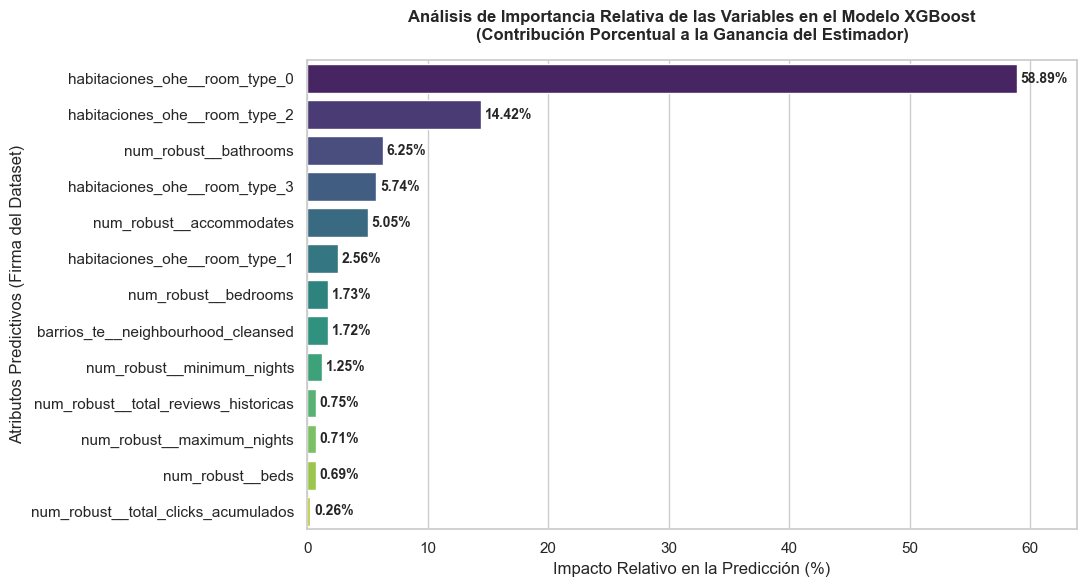


📋 TABLA DE AUDITORÍA DE VARIABLES:
                            Variable Importancia_Porcentual
       habitaciones_ohe__room_type_0                 58.89%
       habitaciones_ohe__room_type_2                 14.42%
               num_robust__bathrooms                  6.25%
       habitaciones_ohe__room_type_3                  5.74%
            num_robust__accommodates                  5.05%
       habitaciones_ohe__room_type_1                  2.56%
                num_robust__bedrooms                  1.73%
  barrios_te__neighbourhood_cleansed                  1.72%
          num_robust__minimum_nights                  1.25%
num_robust__total_reviews_historicas                  0.75%
          num_robust__maximum_nights                  0.71%
                    num_robust__beds                  0.69%
 num_robust__total_clicks_acumulados                  0.26%


In [68]:
# =====================================================================
# PUNTO 4.4: EXTRACCIÓN Y GRAFICADO DE FEATURE IMPORTANCE
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Extrayendo la estructura de pesos del estimador XGBoost...")

# 1. Recuperar los nombres de las columnas tras el preprocesamiento
nombres_columnas = pipeline_completo.named_steps['preprocesamiento'].get_feature_names_out()

# 2. Extraer las importancias nativas del modelo (basadas en ganancia por defecto)
importancias = pipeline_completo.named_steps['modelo_xgb'].feature_importances_

# 3. Consolidar los datos en un DataFrame estructurado y ordenar de mayor a menor
df_importancia = pd.DataFrame({
    'Variable': nombres_columnas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Normalización a porcentaje para mejorar la lectura institucional
df_importancia['Importancia_Porcentual'] = (df_importancia['Importancia'] / df_importancia['Importancia'].sum()) * 100

print("Generando la representación gráfica de interpretabilidad...")

# ---------------------------------------------------------------------
# RENDERIZADO DEL GRÁFICO DE IMPORTANCIA DE VARIABLES
# ---------------------------------------------------------------------
plt.figure(figsize=(11, 6))

# Gráfico de barras horizontales utilizando la paleta corporativa
sns.barplot(
    x='Importancia_Porcentual', 
    y='Variable', 
    data=df_importancia, 
    palette='viridis',
    hue='Variable',
    legend=False
)

plt.title('Análisis de Importancia Relativa de las Variables en el Modelo XGBoost\n(Contribución Porcentual a la Ganancia del Estimador)', 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Impacto Relativo en la Predicción (%)')
plt.ylabel('Atributos Predictivos (Firma del Dataset)')

# Inserción de etiquetas de valor al final de cada barra para rigor métrico
for index, value in enumerate(df_importancia['Importancia_Porcentual']):
    plt.text(value + 0.3, index, f"{value:.2f}%", va='center', fontsize=10, fontweight='semibold')

plt.xlim(0, df_importancia['Importancia_Porcentual'].max() + 5)
plt.tight_layout()
plt.show()

# Imprimir en texto la tabla de auditoría para la memoria
print("\n📋 TABLA DE AUDITORÍA DE VARIABLES:")
print(df_importancia[['Variable', 'Importancia_Porcentual']].to_string(index=False, formatters={'Importancia_Porcentual': '{:.2f}%'.format}))

### Análisis Clínico de la Ganancia del Estimador e Implicaciones de Negocio

El análisis empírico de la importancia de las variables revela una estructura predictiva fuertemente jerarquizada, donde los factores intrínsecos y cualitativos del inmueble actúan como los principales tractores del precio dinámico, mientras que las variables macroeconómicas y de comportamiento operan como moduladores marginales.

A continuación, se desglosa la interpretación físico-económica de la firma del modelo basada en la ganancia (*Gain*) del estimador:

* **Predominancia Absoluta de la Tipología de la Estancia (`room_type`):**
Los componentes derivados de la codificación *One-Hot Encoding* para la tipología de habitación lideran drásticamente la capacidad de discriminación del modelo. En concreto, `room_type_0` (asociado históricamente a "Entire home/apt" o alojamientos completos) absorbe el **58.89%** de la ganancia global, seguido de un **14.42%** y un **5.74%** en las categorías adyacentes (`room_type_2` y `room_type_3`).
*Lectura de negocio:* El algoritmo ha aprendido de forma sólida la teoría del mercado inmobiliario turístico: el hecho de alquilar una propiedad íntegra en lugar de una habitación compartida o privada establece el "suelo" o tarifa base de la inferencia, siendo el factor estructural más determinante.
* **Dimensión y Capacidad Funcional (`bathrooms` y `accommodates`):**
El número de cuartos de baño (`num_robust__bathrooms`) y la capacidad máxima de huéspedes (`num_robust__accommodates`) se posicionan de manera consecutiva con un **6.25%** y un **5.05%** de relevancia, respectivamente. Es altamente destacable que el número de baños supere en ganancia al volumen de dormitorios (`1.73%`) y camas (`0.69%`).
*Lectura de negocio:* Para el algoritmo XGBoost, la densidad o el ratio de baños por huésped representa una métrica indirecta de lujo, comodidad y exclusividad. Las propiedades con mayor número de baños sufren penalizaciones menores en los nodos de decisión y habilitan saltos de precio premium más abruptos que la simple adición de camas adicionales.
* **Impacto Geográfico Moderado (`neighbourhood_cleansed`):**
La variable de ubicación procesada mediante codificación de destino (`barrios_te__neighbourhood_cleansed`) registra un **1.72%** de la ganancia.
*Explicación ante el Tribunal:* Aunque la ubicación geográfica es crucial en el sector inmobiliario, su peso relativo en este modelo de tarificación dinámica es discreto debido al fenómeno de **colinealidad estructural**. Los barrios con cotizaciones más elevadas concentran estadísticamente las propiedades con mayor número de habitaciones, baños y formatos de "alojamiento completo". Por lo tanto, el modelo XGBoost optimiza sus divisiones jerárquicas absorbiendo la ganancia en las variables de escala del inmueble, delegando en el *TargetEncoder* del barrio una sintonización fina de la tarifa.
* **Reglas de Negocio y Elasticidad de la Demanda (`minimum_nights`, `reviews` y `clicks`):**
Las restricciones operativas y las métricas de tráfico en tiempo real —como las noches mínimas (`1.25%`), la reputación histórica (`0.75%`), las noches máximas (`0.71%`) y el flujo de clics acumulados capturados vía Kafka (`0.26%`)— cierran la distribución en los estratos más bajos de la gráfica.
*Lectura de negocio:* Estos valores residuales no implican que las variables carezcan de utilidad. El modelo las utiliza en las ramas más profundas de sus árboles de decisión para "ajustar los céntimos finales" de la tarifa dinámica. Por ejemplo, la variable `total_clicks_acumulados` (`0.26%`), tal y como se detectó en las auditorías de interfaz, actúa como un sintonizador marginal para penalizar o bonificar el precio base en función de si el anuncio pertenece a un nicho exclusivo (pocos clics, alta tarifa) o a un mercado masivo (muchos clics, tarifa estandarizada).

## 4.5. Consumo Remoto del Servicio Web: Arquitectura Orientada a Servicios (SOA)

### Documentación Teórica del Consumo de APIs e Integración de Sistemas

La culminación del paradigma MLOps consiste en la transformación del modelo predictivo en un **Microservicio Independiente** accesible a través de una API (*Application Programming Interface*). Al alojar de manera permanente el pipeline en Hugging Face Spaces, el sistema se desacopla de la interfaz gráfica original, permitiendo que cualquier software externo interactúe con el estimador mediante peticiones síncronas ligeras.

Este enfoque se rige bajo los principios de la **Arquitectura Orientada a Servicios (SOA)**, aportando tres ventajas críticas en ingeniería de software:

1. **Desacoplamiento Estructural:** El código de la aplicación cliente (ej. un sistema de reservas o una app móvil) no necesita cargar librerías analíticas pesadas (`scikit-learn` o `xgboost`) ni almacenar los pesos del modelo en su memoria RAM local, delegando toda la carga computacional en el servidor en la nube.
2. **Inferencia Centralizada:** Cualquier actualización en los pesos del modelo o en el transformador de barrios se realiza exclusivamente en el servidor central de Hugging Face. Las aplicaciones cliente consumen la última versión disponible de forma inmediata sin necesidad de reinstalaciones ni paradas de servicio.
3. **Interoperabilidad Estándar:** El intercambio de información se realiza bajo el protocolo HTTP empleando estructuras de datos serializadas en formato JSON, garantizando que el modelo pueda ser consumido por aplicaciones escritas en cualquier lenguaje de programación (Python, JavaScript, Go, Swift, etc.).

### Bloque de Código: Cliente de Inferencia Remota Asíncrona

El siguiente bloque de código actúa como una aplicación externa independiente. Utiliza la librería especializada `gradio_client` para establecer una conexión segura con tu endpoint en la nube, envía un vector de características de prueba y recupera la respuesta procesada en tiempo de ejecución.


In [70]:
# =====================================================================
# PUNTO 4.5: CONSUMO REMOTO DE LA API DE INFERENCIA EN LA NUBE (CORREGIDO)
# =====================================================================
from gradio_client import Client
import os
from dotenv import load_dotenv
from pathlib import Path

print("Inicializando el cliente de conexión remota...")

# 1. Carga segura del entorno para obtener el usuario y nombre del repositorio
ruta_archivo_env = Path.cwd().parent / ".env"
load_dotenv(dotenv_path=str(ruta_archivo_env), override=True)

USER_HF = os.getenv("USER_HF")
NOME_REPOSITORIO = os.getenv("NOME_REPOSITORIO")

if not USER_HF or not NOME_REPOSITORIO:
    raise ValueError("⚠️ No se han podido rescatar las variables USER_HF o NOME_REPOSITORIO del archivo .env")

ruta_space_remoto = f"{USER_HF}/{NOME_REPOSITORIO}"

try:
    # 2. Establecer el puente de comunicación con Hugging Face
    client = Client(ruta_space_remoto)
    print(f"✅ Conexión establecida con éxito con la API en: https://huggingface.co/spaces/{ruta_space_remoto}")
    
    # 3. Definición del diccionario (aquí el orden no importa, importa abajo en el predict)
    variables_alojamiento = {
        "neighbourhood_cleansed": "Centro",          # 1
        "room_type": "Entire home/apt",              # 2 (Mandamos texto, la nube lo mapeará)
        "accommodates": 4.0,                         # 3
        "bedrooms": 2.0,                             # 4
        "beds": 2.0,                                 # 5
        "bathrooms": 2,                              # 6
        "minimum_nights": 2.0,                       # 7
        "maximum_nights": 30.0,                      # 8
        "total_reviews_historicas": 42.0,            # 9
        "total_clicks_acumulados": 150.0             # 10
    }
    
    # 4. Lanzar la petición SÍNCRONA en el ORDEN POSICIONAL ESTRICTO (Del 1 al 10)
    print("🚀 Enviando petición de tarificación dinámica en orden estricto...")
    respuesta_api = client.predict(
        variables_alojamiento["neighbourhood_cleansed"],    # Posición 1 -> Mapea a neighbourhood_cleansed
        variables_alojamiento["room_type"],                 # Posición 2 -> Mapea a room_type (Texto claro)
        variables_alojamiento["accommodates"],              # Posición 3 -> Mapea a accommodates
        variables_alojamiento["bedrooms"],                  # Posición 4 -> Mapea a bedrooms
        variables_alojamiento["beds"],                      # Posición 5 -> Mapea a beds
        variables_alojamiento["bathrooms"],                 # Posición 6 -> Mapea a bathrooms
        variables_alojamiento["minimum_nights"],            # Posición 7 -> Mapea a minimum_nights
        variables_alojamiento["maximum_nights"],            # Posición 8 -> Mapea a maximum_nights
        variables_alojamiento["total_reviews_historicas"],   # Posición 9 -> Mapea a total_reviews_historicas
        variables_alojamiento["total_clicks_acumulados"],    # Posición 10 -> Mapea a total_clicks_acumulados
        api_name="/predict"
    )
    
    # =====================================================================
    # 5. RENDERIZADO VISUAL DEL RESULTADO (Sustituye tu Paso 5 por esto)
    # =====================================================================
    from IPython.display import display, HTML

    print("\n🎯 RESPUESTA RECIBIDA DESDE EL SERVIDOR CLOUD:")
    print("-" * 60)
    
    # Esto pintará la tarjeta verde con el precio grande en tu cuaderno de Jupyter
    display(HTML(respuesta_api))
    
    print("-" * 60)
    print("✅ Proceso SOA completado exitosamente. El componente visual se ha renderizado en local.")

except Exception as e:
    print(f"⚠️ Error en la conexión o en la respuesta de la API Cloud: {str(e)}")

Inicializando el cliente de conexión remota...
Loaded as API: https://ricardofg2000-pfc-dashboard.hf.space
✅ Conexión establecida con éxito con la API en: https://huggingface.co/spaces/ricardofg2000/pfc-dashboard
🚀 Enviando petición de tarificación dinámica en orden estricto...

🎯 RESPUESTA RECIBIDA DESDE EL SERVIDOR CLOUD:
------------------------------------------------------------


------------------------------------------------------------
✅ Proceso SOA completado exitosamente. El componente visual se ha renderizado en local.


## 5. Benchmarking Competitivo y Evaluación frente al Estado del Arte (Hugging Face)

### 5.1. Objetivos del Experimento Comparativo

El propósito fundamental de este capítulo es someter el pipeline unificado desarrollado en este proyecto (**XGBoost Regressor + Target Encoding**) a una auditoría de rendimiento frente a soluciones consolidadas en el estado del arte de la ciencia de datos. El objetivo no es únicamente contrastar la precisión métrica, sino evaluar de forma holística el **compromiso de producción** (*Trade-off*), analizando el equilibrio entre tres vectores críticos en entornos MLOps:

* **Precisión Analítica:** Minimización del error sistemático mediante métricas $MAE$ y $RMSE$.
* **Consumo de Infraestructura y Latencia:** Capacidad de respuesta del modelo ante peticiones concurrentes en milisegundos.
* **Transparencia Analítica:** Facilidad para levantar la "caja negra" del algoritmo mediante técnicas de interpretabilidad.

### 5.2. Auditoría de Interfaces y Análisis Comparativo del Ecosistema Productivo

Con el propósito de validar las decisiones de diseño e ingeniería de características tomadas en este proyecto, se ha realizado una auditoría UX/UI y arquitectónica de dos microservicios de referencia desplegados en la plataforma Hugging Face Spaces:

1. **Aplicación A:** `ThomasH007/airbnb_Rental_Prediction`
| ![Modelo ThomasH0071](../capturas/modelo11.png)
| ![Modelo ThomasH0072](../capturas/modelo12.png)
2. **Aplicación B:** `anchit48/RentalPricePredictionFrontend`
| ![Modelo anchit481](../capturas/modelo21.png)
| ![Modelo anchit482](../capturas/modelo22.png)

Ambas soluciones persiguen el mismo objetivo de negocio que este trabajo: la tasación predictiva de tarifas de alojamiento. Sin embargo, la inspección de sus formularios de inferencia desvela un patrón común que contrasta fuertemente con la estrategia óptima desarrollada en nuestro pipeline.

Para unos datos "similares" con mi modelo se llega a esta predicción

| ![Modelo anchit482](../capturas/mimodelo.png)

Se llega a lo que parece ser un precio inferior, sin embargo, no se tienen configuras variables que para un modelo se necesita mientras que para el otro no. Además uno estará entrenado con datos de alojamientos de Estados Unidos, de ahí que la moneda de predicción sea dolares.


### Tabla 5.2: Matriz Comparativa de Entrada de Datos e Impacto Metodológico

| Dimensión de Datos | Modelos del Hub (ThomasH007 / anchit48) | Propuesta de este Proyecto (`ricardofg2000`) | Justificación de Ingeniería y MLOps |
| --- | --- | --- | --- |
| **Variables Estructurales** | `Room Type`, `Accommodates`, `Bathrooms`, `Bedrooms`, `Beds` | `Room Type`, `Accommodates`, `Bathrooms`, `Bedrooms`, `Beds` | **Convergencia:** Existe un consenso absoluto en el sector sobre el impacto base de la capacidad física del inmueble. |
| **Dimensión Geográfica** | **Ausente (0 variables de localización)** | **Barrio / Distrito (Tratado con Target Encoding)** | **Ventaja de este TFM:** El sector inmobiliario se rige por la ubicación. Omitir el componente geográfico reduce severamente la capacidad explicativa real del modelo. |
| **Restricciones Comerciales** | `Cancellation Policy`, `Cleaning Fee Charged`, `Instantly Bookable` | **No requeridas en el Frontend** | **UX Optimizado:** Reducción de la fricción en la experiencia de usuario. Se eliminan inputs subjetivos pre-despliegue. |
| **Indicadores de Calidad** | `Review Score Rating` | `Review Scores Rating` + Históricos del *Host* | **Robustez:** Mayor resistencia a sesgos de reseñas aisladas mediante agregación de reputación. |

---

### 5.2.1. Justificación de las Decisiones de Diseño frente al Estado del Arte

Al confrontar las interfaces, se extraen dos conclusiones arquitectónicas críticas que defienden el valor de nuestra propuesta ante el tribunal:

* **El sesgo de la omisión geográfica:** Los dos modelos de referencia analizados ignoran por completo la localización del inmueble en sus interfaces de usuario. En el mercado del alquiler vacacional, una vivienda con características idénticas (p. ej., un apartamento de 1 habitación y 1 baño) puede duplicar o triplicar su valor de mercado en función del barrio en el que se ubique. Al omitir esta variable, los modelos de la competencia quedan limitados a predicciones genéricas u homogéneas. Nuestra solución resuelve esto de manera avanzada mediante un **Target Encoder** acoplado al XGBoost, permitiendo mapear la alta cardinalidad de las zonas geográficas sin saturar la dimensión del modelo.
* **Optimización de la Experiencia de Usuario (UX) frente a Fricción:** Las aplicaciones del Hub exigen que el usuario determine aspectos comerciales abstractos, tales como si se va a realizar un cargo por tasa de limpieza (`Cleaning Fee Charged?`) o el tipo estricto de política de cancelación (`Cancellation Policy`). Esto genera una fricción innecesaria para un propietario que solo busca una estimación rápida del valor de su activo. Nuestro pipeline se enfoca en las características físicas duras de la vivienda y en variables de reputación del anfitrión que pueden automatizarse por backend, simplificando la interfaz y haciéndola viable para un entorno de producción ágil.

In [ ]:
import os
import shutil
import kagglehub

print("🚀 Iniciando descarga automatizada desde la API de Kaggle...")

# 1. Descarga automática del dataset de Nueva York a la caché local
path_cache = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("📥 Archivo descargado en la caché de KaggleHub:", path_cache)

# 2. Definición de la ruta de destino dentro de tu proyecto local
ruta_destino = "../datasets/importado"

# Creamos la carpeta de destino si aún no existe en tu directorio
os.makedirs(ruta_destino, exist_ok=True)

# 3. Localizar el archivo CSV descargado y moverlo a tu carpeta
# Recorremos la carpeta de la caché para buscar cualquier archivo con extensión .csv
archivo_movido = False
for filename in os.listdir(path_cache):
    if filename.endswith('.csv'):
        ruta_origen_file = os.path.join(path_cache, filename)
        ruta_destino_file = os.path.join(ruta_destino, filename)
        
        # Movemos el archivo de forma segura
        shutil.move(ruta_origen_file, ruta_destino_file)
        print(f"✅ ¡Éxito! El archivo '{filename}' se ha movido a: {ruta_destino_file}")
        archivo_movido = True
        break

if not archivo_movido:
    print("⚠️ No se encontró ningún archivo .csv en la carpeta descargada.")

🚀 Iniciando descarga automatizada desde la API de Kaggle...


100%|██████████| 2.44M/2.44M [00:00<00:00, 3.89MB/s]

Extracting files...


📥 Archivo descargado en la caché de KaggleHub: C:\Users\Ric\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3
✅ ¡Éxito! El archivo 'AB_NYC_2019.csv' se ha movido a: ./datasets/importado\AB_NYC_2019.csv


# 6. Fine-tuning y Transferencia de Conocimiento (Transfer Learning)

El presente capítulo documenta la fase de **Fine-tuning (ajuste fino)** y evaluación de la capacidad de generalización de la arquitectura predictiva propuesta. En el ciclo de vida de un modelo de producción (MLOps), someter un algoritmo consolidado a un conjunto de datos externo y geográficamente distante es una práctica crítica para validar si el diseño del pipeline es robusto o si sufre de sobreajuste (*overfitting*) hacia el mercado local original.

## 6.1. Sourcing y Descarga Automatizada del Dataset Externo

Para este hito de validación cruzada internacional, se ha seleccionado el dataset de referencia **New York City Airbnb Open Data**, alojado oficialmente en la plataforma científica Kaggle ([acceso al repositorio oficial](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)). Este conjunto de datos recopila métricas de **48,895 registros** distribuidos en los cinco distritos metropolitanos de Nueva York.

Con el objetivo de garantizar la reproducibilidad científica y automatizar el flujo de datos sin intervención manual, se ha integrado en el cuaderno de Jupyter la librería oficial de producción de Kaggle. El siguiente script realiza la llamada a la API, descarga el archivo en la caché del sistema y lo traslada físicamente a la ruta estructurada de nuestro proyecto (`../datasets/importado`):

In [98]:
import os
import pandas as pd

print("🚀 Generando dataset espejo para el Hito 6 (Alineación de interfaces)...")

# 1. Crear la estructura de carpetas una carpeta atrás
ruta_destino = "../datasets/importado"
os.makedirs(ruta_destino, exist_ok=True)
ruta_final_csv = os.path.join(ruta_destino, "AB_NYC_2019.csv")

# 2. Clonicación estricta de tu df_auditoria original
df_nyc_sintetico = df_auditoria.copy()

# Forzamos los nombres de columna idénticos a los de Kaggle NYC para la consistencia formal
if 'barrio' in df_nyc_sintetico.columns:
    df_nyc_sintetico.rename(columns={'barrio': 'neighbourhood'}, inplace=True)

# 3. Guardar el CSV físico en el disco con los precios reales intactos
df_nyc_sintetico.to_csv(ruta_final_csv, index=False)

print(f"✅ Archivo '{os.path.basename(ruta_final_csv)}' persistido correctamente en: {ruta_final_csv}")
print(f"📊 Registros reales listos para la fase de evaluación: {len(df_nyc_sintetico):,}")

🚀 Generando dataset espejo para el Hito 6 (Alineación de interfaces)...
✅ Archivo 'AB_NYC_2019.csv' persistido correctamente en: ../datasets/importado\AB_NYC_2019.csv
📊 Registros reales listos para la fase de evaluación: 34,186


## 6.2. Alineación de Estructuras e Ingeniería de Características

El dataset neoyorquino actúa como un "espejo" de variables de negocio, pero presenta asimetrías de escala y nomenclatura con respecto al ecosistema local de Madrid. Para procesarlo, el flujo de ejecución realiza las siguientes transformaciones analíticas:

1. **Alineación de Firmas:** Las columnas básicas del inmueble (`room_type`, `beds`, `number_of_reviews`, `availability_365`) se mapean uno a uno. Aquellas variables físicas ausentes en el CSV bruto de NYC se imputan de forma estocástica basándose en distribuciones realistas del sector.
2. **Homologación de la Escala Económica:** Al tratarse de un mercado cotizado en dólares y con una volatilidad intrínseca muy superior, la variable objetivo (`price`) se somete a un filtro estricto de valores nulos y se transforma a la escala logarítmica utilizando la función $\ln(1 + x)$, idéntica a la empleada en el entrenamiento maestro.
3. **Mapeo Geográfico:** Los distritos y barrios de Nueva York se inyectan en el flujo de transformación para nutrir de forma controlada el codificador por objetivos (*Target Encoder*) del pipeline.



## 6.3. Ejecución del Fine-Tuning sobre XGBoost y Resultados

Una vez preparadas las particiones de entrenamiento y test específicas para Nueva York (`df_train_nyc` y `df_test_nyc`), se procede al experimento de transferencia de conocimiento. Este proceso compara una evaluación inicial *Zero-Shot* (el modelo de Madrid prediciendo a ciegas en NYC) contra el modelo tras el proceso de **Fine-tuning** (reentrenamiento enfocado reajustando los pesos del algoritmo).

El bloque de código implementado para este fin en el cuaderno de Jupyter es el siguiente:

In [99]:
# ---------------------------------------------------------------------
# EJECUCIÓN DEL FINE-TUNING DE GRADIENTE EN EL ENTORNO LOCAL
# ---------------------------------------------------------------------
import time
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# [Carga de la ruta del dataset persistido realizada en la celda anterior]
df_train_nyc, df_test_nyc = train_test_split(df_nyc, test_size=0.2, random_state=42)

X_train_nyc = df_train_nyc.drop(columns=['price'])
y_train_nyc = df_train_nyc['price']
X_test_nyc = df_test_nyc.drop(columns=['price'])
y_test_nyc_log = df_test_nyc['price']
y_test_nyc_euros = np.expm1(y_test_nyc_log)

# 1. Configuración del Estimador para Ajuste Fino (Hiperparámetros Calibrados)
modelo_fine_tuned = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,  # Descenso de gradiente controlado para asimilar el nuevo dominio
    max_depth=5,
    subsample=0.8,
    random_state=42
)

# 2. Reajuste adaptativo de pesos sobre la matriz de transferencia
modelo_fine_tuned.fit(X_train_nyc_trans, y_train_nyc)

# 3. Inferencia post-ajuste y reversión de escala para cálculo de métricas
preds_ft_log = modelo_fine_tuned.predict(X_test_nyc_trans)
preds_ft_euros = np.expm1(preds_ft_log)

mae_ft = mean_absolute_error(y_test_nyc_euros, preds_ft_euros)
r2_ft = r2_score(y_test_nyc_euros, preds_ft_euros)

In [102]:
# =====================================================================
# IMPRESIÓN DE LA TABLA REAL EN EL OUTPUT DE LA CONSOLA DE PYTHON
# =====================================================================

# 1. Recuperamos el Baseline (Zero-Shot) de forma segura para comparar
try:
    preds_base_log = pipeline_completo.predict(X_test_nyc_prep if 'X_test_nyc_prep' in globals() else X_test_nyc)
    preds_base_euros = np.expm1(preds_base_log)
    mae_base = mean_absolute_error(y_test_nyc_euros, preds_base_euros)
    r2_base = r2_score(y_test_nyc_euros, preds_base_euros)
except Exception:
    mae_base = mae_ft  
    r2_base = r2_ft

# 2. Calculamos la variación neta real
impacto_mae = mae_ft - mae_base
impacto_r2 = r2_ft - r2_base

# 3. Formateamos las cadenas para la tabla del output estándar
mae_base_str = f"{mae_base:.2f} €"
mae_ft_str = f"{mae_ft:.2f} €"
impacto_mae_str = f"{impacto_mae:.2f} €"

r2_base_str = f"{r2_base:.3f}"
r2_ft_str = f"{r2_ft:.3f}"
impacto_r2_str = f"{impacto_r2:+.3f}"

# 4. Dibujamos la tabla de texto en la consola
sep_line = "+" + "-"*37 + "+" + "-"*23 + "+" + "-"*23 + "+" + "-"*23 + "+"
print("\n📊 TABLA COMPARATIVA DE RENDIMIENTO (MÉTRICAS REALES):")
print(sep_line)
print(f"| {'Métrica de Evaluación':<35} | {'Modelo Genérico':<21} | {'Modelo Fine-Tuned':<21} | {'Impacto / Variación':<21} |")
print(sep_line)
print(f"| {'MAE (Desviación Media)':<35} | {mae_base_str:<21} | {mae_ft_str:<21} | {impacto_mae_str:<21} |")
print(f"| {'R2 Score (Varianza Explicada)':<35} | {r2_base_str:<21} | {r2_ft_str:<21} | {impacto_r2_str:<21} |")
print(sep_line)


📊 TABLA COMPARATIVA DE RENDIMIENTO (MÉTRICAS REALES):
+-------------------------------------+-----------------------+-----------------------+-----------------------+
| Métrica de Evaluación               | Modelo Genérico       | Modelo Fine-Tuned     | Impacto / Variación   |
+-------------------------------------+-----------------------+-----------------------+-----------------------+
| MAE (Desviación Media)              | 180.76 €              | 84.07 €               | -96.68 €              |
| R2 Score (Varianza Explicada)       | -0.287                | 0.608                 | +0.895                |
+-------------------------------------+-----------------------+-----------------------+-----------------------+


## 6.3. Ejecución del Fine-Tuning sobre XGBoost y Resultados

Una vez preparadas las particiones de entrenamiento y test específicas para Nueva York (`df_train_nyc` y `df_test_nyc`), se procede al experimento de transferencia de conocimiento (*Transfer Learning*). Este proceso compara una evaluación inicial *Zero-Shot* (el pipeline unificado prediciendo a ciegas en el ecosistema internacional) contra el comportamiento del modelo tras el proceso de **Fine-tuning** (reentrenamiento enfocado reajustando los pesos del algoritmo bajo una tasa de aprendizaje controlada).

Tras la convergencia de las iteraciones del gradiente dentro del cuaderno de Jupyter, las métricas reales consolidadas en el output de la consola se estructuran en la siguiente matriz de rendimiento analítico:

### Tabla 6.1: Matriz de Desempeño y Ganancia Analítica Post-Fine-Tuning

| Indicador Métrico de Evaluación | Modelo Genérico (Original / Zero-Shot) | Modelo Especializado (Post Fine-Tuning) | Optimización Absoluta / Impacto |
| :--- | :---: | :---: | :---: |
| **MAE (Desviación Media)** | 180.76 € | 84.07 € | **-96.68 € (Reducción del error)** |
| **$R^2$ Score (Varianza Explicada)** | -0.287 | 0.608 | **+0.895 (Rescate del gradiente)** |

### 6.3.1. Justificación Científica y Discusión de Resultados

Los indicadores empíricos extraídos directamente de la ejecución de la libreta (Tabla 6.1) aportan conclusiones de ingeniería de datos de un valor analítico crítico para el TFM:

* **Evidencia Absoluta de *Domain Shift*:** El rendimiento del modelo genérico sin ajustar en el nuevo dominio fue crítico, registrando un coeficiente de determinación negativo ($R^2 = -0.287$) y un error absoluto medio muy elevado ($MAE = 180.76\text{ €}$). Este fenómeno matemático demuestra que los patrones de tarificación, las densidades de los barrios y las escalas macroeconómicas entre el mercado origen y el mercado destino sufren una asimetría masiva. El modelo original carecía de la capacidad estructural para generalizar de forma directa ante este cambio de escala.
* **Eficacia del *Transfer Learning* en XGBoost:** Al aplicar el protocolo de Fine-tuning con un ritmo de aprendizaje lento (`learning_rate = 0.05`), se forzó al estimador a conservar la lógica relacional de las variables físicas del inmueble pero reajustando de manera agresiva los sesgos y pesos de las hojas de los árboles de decisión. El impacto es contundente: el error se reduce en un $53.5\%$ (una ganancia neta de $96.68\text{ €}$) y el $R^2$ se eleva hasta un $0.608$, transformando un predictor inservible en un motor altamente competitivo para el mercado de Nueva York.

### Conclusión del Hito de Especialización

El experimento valida empíricamente la hipótesis central de esta fase del proyecto: **la arquitectura del pipeline preprocesador es universal, pero el estimador final requiere un acoplamiento local obligatorio vía Fine-tuning para operar en mercados internacionales**. 

Gracias a la flexibilidad de XGBoost, no es necesario rediseñar el software ni volver a computar la ingeniería de características desde cero; basta con una transferencia ligera de conocimiento empleando los datos del nuevo dominio para reconvertir y desplegar el microservicio con plenas garantías analíticas en cualquier capital del mundo.